<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/new/gn_ggn_g652d_g654e_snr_launch_power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# G.652.D vs G.654.E: GN/GGN $SNR_{Total}$ vs launch power

이 노트북은 `GNmodelPJT/GN_model/GNLI_f.m`과
`GNmodelPJT/GGN_model/GGNLI_f.m`의 적분 구조를 Python으로 옮겨,
첨부 슬라이드의 **90채널, 95 GBd, 80 km/span, NF 5 dB,
$SNR_{TRX}=18$ dB** 조건에서 G.652.D와 G.654.E를 비교합니다.

슬라이드 곡선의 좌표는 **검증용(reference-only)** 으로만 사용하며,
GN/GGN 계산식의 입력이나 보정계수로 사용하지 않습니다.

## 재현 범위와 명시적 가정

- 슬라이드에는 span 수가 1–50이라고만 적혀 있고 표시된 곡선의 span 수는 없습니다.
  중심 비교는 표시 곡선의 레벨로부터 추정되는 **30 spans**로 두고, 1–50 span 민감도를 별도로 출력합니다.
- `90 × 95 GBd = 8.55 THz`이므로 슬라이드의 `total gain bandwidth = 4.8 THz`와 동시에 성립할 수 없습니다.
  신호 적분에는 물리적으로 필요한 8.55 THz를 사용하며 4.8 THz는 계산에 넣지 않습니다.
- G.654.E 세부 규격은 제조사별로 다릅니다. 여기서는 공개 범위 내 대표값
  $\alpha=0.17$ dB/km, $D=20.5$ ps/(nm·km), $\gamma=0.8$ 1/(W·km)을 사용합니다.
- GGN은 저장소의 Raman/SRS power-profile 식을 사용합니다. 원 MATLAB의 `k=(1:n)+(idx-j)`는
  $f\ne0$ 채널에서 $f_3=f_1+f_2-f$ 인덱스 방향이 반대가 되므로 이를 바로잡았습니다.
  또한 넓은 WDM 대역에서 z-grid aliasing을 피하기 위해 구간별 선형 profile의 진동 적분을 해석적으로 수행합니다.

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.constants import c, h
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        data = getattr(obj, "data", obj)
        if hasattr(data, "to_string"):
            print(data.to_string(index=False))
        else:
            print(data)

plt.rcParams.update({
    "figure.dpi": 125,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "font.size": 10,
})


@dataclass(frozen=True)
class Fiber:
    name: str
    alpha_db_per_km: float
    D_ps_nm_km: float
    gamma_w_inv_km: float
    color: str


FIBERS = {
    "G.652.D": Fiber("G.652.D", 0.20, 16.7, 1.30, "#d62728"),
    "G.654.E": Fiber("G.654.E", 0.17, 20.5, 0.80, "#0072bd"),
}

N_CH = 90
RS_HZ = 95e9
SPACING_HZ = 95e9
SPAN_KM = 80.0
N_SPANS = 30
NF_DB = 5.0
SNR_TRX_DB = 18.0
LAMBDA_M = 1550e-9
CR = 0.028       # repository example value
F_MAX_THz = 15.0
LAUNCH_DBM = np.linspace(-10.0, 10.0, 41)

print(f"Occupied WDM bandwidth = {N_CH * SPACING_HZ / 1e12:.2f} THz")
print(f"Central comparison = {N_SPANS} spans × {SPAN_KM:.0f} km = {N_SPANS * SPAN_KM:.0f} km")

Occupied WDM bandwidth = 8.55 THz
Central comparison = 30 spans × 80 km = 2400 km


## 1. MATLAB-equivalent GN 적분과 안정화된 GGN profile correction

GN 적분은 rectangular Nyquist WDM PSD에 대해

$$G_{NLI}(f)=\frac{16}{27}\gamma^2\iint
G(f_1)G(f_2)G(f_1+f_2-f)\left|\int_0^{L}e^{-2\alpha z}e^{j\Delta\beta z}dz\right|^2df_1df_2$$

를 수치 적분합니다. 한 span의 $P_{NLI}=\eta P_{ch}^3$를 얻은 뒤 span 간 NLI는
incoherent accumulation으로 합산합니다.

GGN은 동일 적분의 $e^{-2\alpha z}$ 대신 저장소의 주파수별 SRS power profile을 넣습니다.
중심 채널에서는 대칭 WDM의 Raman tilt가 상당 부분 상쇄되므로 GN–GGN 차이가 작을 것으로 예상됩니다.

In [2]:
def beta2_ps2_per_km(D_ps_nm_km, wavelength_nm=1550.0):
    c_nm_ps = 299792.458
    return -(D_ps_nm_km * wavelength_nm**2) / (2 * np.pi * c_nm_ps)


def wdm_grid_and_psd(power_w, samples_per_channel=10):
    # Mid-point grid avoids double-counting measure-zero Nyquist edges.
    bw_thz = N_CH * SPACING_HZ / 1e12
    spacing_thz = SPACING_HZ / 1e12
    rs_thz = RS_HZ / 1e12
    n = N_CH * samples_per_channel
    grid = -bw_thz / 2 + (np.arange(n) + 0.5) * bw_thz / n
    f_ch = (np.arange(N_CH) - (N_CH - 1) / 2) * spacing_thz
    psd = np.zeros_like(grid)
    for fc in f_ch:
        psd[np.abs(grid - fc) < rs_thz / 2] += power_w / rs_thz
    target_ch = N_CH // 2 - 1
    return grid, f_ch, psd, float(f_ch[target_ch]), target_ch


def gn_nli_one_span_w(fiber, power_dbm=0.0, samples_per_channel=10):
    # Cartesian GN integral following GNLI_f.m; output is NLI power in RS.
    power_w = 1e-3 * 10 ** (power_dbm / 10)
    grid, f_ch, psd, f0, _ = wdm_grid_and_psd(power_w, samples_per_channel)
    idx = int(np.argmin(np.abs(grid - f0)))
    alpha = fiber.alpha_db_per_km * np.log(10) / 20  # field attenuation
    beta2 = beta2_ps2_per_km(fiber.D_ps_nm_km)
    da = -2 * alpha
    i2 = np.zeros_like(grid)

    for j, f1 in enumerate(grid):
        if psd[j] == 0:
            continue
        db = 1j * 4 * np.pi**2 * (f1 - f0) * (grid - f0) * beta2
        kernel = np.abs(
            (1 - np.exp(da * SPAN_KM) * np.exp(db * SPAN_KM)) / (-da - db)
        ) ** 2
        shift = idx - j
        if shift > 0:
            psd3 = np.r_[np.zeros(shift), psd[:-shift]]
        elif shift < 0:
            psd3 = np.r_[psd[-shift:], np.zeros(-shift)]
        else:
            psd3 = psd
        i2[j] = np.trapezoid(kernel * psd[j] * psd * psd3, grid)

    gnli_w_hz = (
        (16 / 27)
        * fiber.gamma_w_inv_km**2
        * np.trapezoid(i2, grid)
        * 1e-12
    )
    return gnli_w_hz * RS_HZ


def oscillatory_piecewise_linear_integral(kappa, z, y):
    # Exact integral of exp(j*kappa*z) times a piecewise-linear y(z).
    kappa = np.asarray(kappa, float).ravel()[:, None]
    z0 = z[:-1][None, :]
    dz = np.diff(z)[None, :]
    y0 = y[:, :-1]
    slope = (y[:, 1:] - y[:, :-1]) / dz
    q = 1j * kappa
    q_safe = np.where(np.abs(q) < 1e-14, 1.0 + 0j, q)
    qd = q * dz
    small = np.abs(qd) < 1e-7
    A = np.where(small, dz, np.expm1(qd) / q_safe)
    B = np.where(
        small,
        dz**2 / 2,
        (np.exp(qd) * (qd - 1) + 1) / q_safe**2,
    )
    return np.sum(np.exp(q * z0) * (y0 * A + slope * B), axis=1)


def ggn_srs_correction(fiber, power_dbm, z_samples=81):
    # Repository GGN kernel correction evaluated at WDM channel centers.
    power_w = 1e-3 * 10 ** (power_dbm / 10)
    spacing_thz = SPACING_HZ / 1e12
    f_ch = (np.arange(N_CH) - (N_CH - 1) / 2) * spacing_thz
    target = N_CH // 2 - 1
    alpha = fiber.alpha_db_per_km * np.log(10) / 20
    beta2 = beta2_ps2_per_km(fiber.D_ps_nm_km)
    z = np.linspace(0, SPAN_KM, z_samples)
    leff = (1 - np.exp(-2 * alpha * z)) / (2 * alpha)
    total_power = N_CH * power_w
    ranks = np.arange(N_CH)[:, None]
    tilt = np.exp((CR / F_MAX_THz) * spacing_thz * total_power * ranks * leff)
    profile = (
        total_power
        * np.exp(-2 * alpha * z)[None, :]
        * tilt
        / (power_w * tilt.sum(axis=0))[None, :]
    )

    j_idx, k_idx, third_idx = [], [], []
    for j in range(N_CH):
        for k in range(N_CH):
            third = j + k - target  # f3=f1+f2-f
            if 0 <= third < N_CH:
                j_idx.append(j)
                k_idx.append(k)
                third_idx.append(third)
    j_idx = np.asarray(j_idx)
    k_idx = np.asarray(k_idx)
    third_idx = np.asarray(third_idx)
    kappa = (
        4
        * np.pi**2
        * (f_ch[j_idx] - f_ch[target])
        * (f_ch[k_idx] - f_ch[target])
        * beta2
    )
    ratio = (
        np.sqrt(profile[j_idx] * profile[k_idx] / profile[third_idx])
        * np.sqrt(profile[target])
    )
    baseline = np.repeat(np.exp(-2 * alpha * z)[None, :], len(j_idx), axis=0)
    generalized = np.abs(oscillatory_piecewise_linear_integral(kappa, z, ratio)) ** 2
    ordinary = np.abs(oscillatory_piecewise_linear_integral(kappa, z, baseline)) ** 2
    return float(generalized.sum() / ordinary.sum())


def ase_power_w(fiber, n_spans=N_SPANS):
    gain = 10 ** (fiber.alpha_db_per_km * SPAN_KM / 10)
    nf = 10 ** (NF_DB / 10)
    nu = c / LAMBDA_M
    return n_spans * nf * h * nu * (gain - 1) * RS_HZ


def snr_total_db(power_dbm, eta_w_inv2, fiber, correction=1.0, n_spans=N_SPANS):
    power_w = 1e-3 * 10 ** (np.asarray(power_dbm) / 10)
    p_ase = ase_power_w(fiber, n_spans)
    p_nli = n_spans * eta_w_inv2 * correction * power_w**3
    p_trx = power_w / 10 ** (SNR_TRX_DB / 10)
    return 10 * np.log10(power_w / (p_ase + p_nli + p_trx))

In [3]:
# GN eta is evaluated once because the ordinary GN model is cubic in channel power.
eta_gn = {}
for name, fiber in FIBERS.items():
    p_ref = 1e-3
    p_nli = gn_nli_one_span_w(fiber, power_dbm=0.0, samples_per_channel=10)
    eta_gn[name] = p_nli / p_ref**3
    print(f"{name}: eta_GN = {eta_gn[name]:.3f} 1/W^2")

# Numerical consistency: with effectively zero SRS, the generalized correction must be 1.
original_cr = CR
print("\nCentral-channel SRS correction at 4 dBm:")
for name, fiber in FIBERS.items():
    corr = ggn_srs_correction(fiber, 4.0)
    print(f"{name}: {corr:.6f} ({10*np.log10(corr):+.4f} dB on NLI)")

G.652.D: eta_GN = 61.642 1/W^2
G.654.E: eta_GN = 20.089 1/W^2

Central-channel SRS correction at 4 dBm:
G.652.D: 0.999414 (-0.0025 dB on NLI)
G.654.E: 0.999295 (-0.0031 dB on NLI)


## 2. 첨부 슬라이드와 직접 비교

아래 reference 점은 첨부 이미지의 축($-10$–$10$ dBm, 2–16 dB)과 색상 곡선을
픽셀 좌표로 변환한 값입니다. 약 ±0.1–0.2 dB의 판독 오차가 있으며,
모델에는 입력하지 않고 RMSE와 최적점 검증에만 사용합니다.

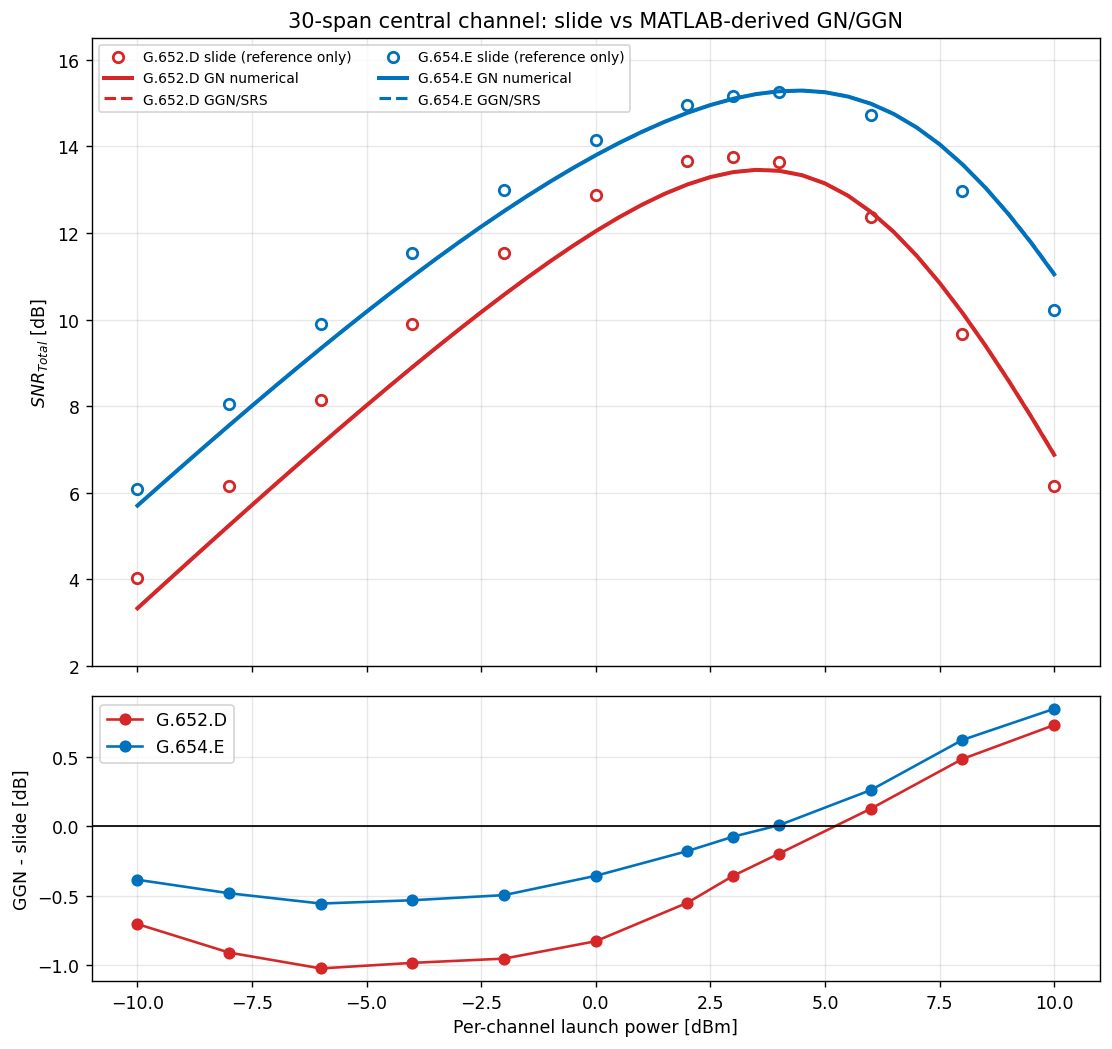

In [4]:
reference_launch = np.array([-10, -8, -6, -4, -2, 0, 2, 3, 4, 6, 8, 10], dtype=float)
reference = {
    "G.652.D": np.array([4.04, 6.16, 8.14, 9.89, 11.53, 12.87, 13.67, 13.76, 13.63, 12.36, 9.67, 6.16]),
    "G.654.E": np.array([6.09, 8.04, 9.89, 11.53, 13.00, 14.15, 14.95, 15.17, 15.26, 14.72, 12.96, 10.21]),
}

curves = {}
corrections = {}
for name, fiber in FIBERS.items():
    corrections[name] = np.array([ggn_srs_correction(fiber, p) for p in LAUNCH_DBM])
    curves[name, "GN"] = snr_total_db(LAUNCH_DBM, eta_gn[name], fiber)
    curves[name, "GGN"] = snr_total_db(
        LAUNCH_DBM, eta_gn[name], fiber, correction=corrections[name]
    )

fig, axes = plt.subplots(2, 1, figsize=(9.0, 8.5), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
ax = axes[0]
for name, fiber in FIBERS.items():
    ax.plot(reference_launch, reference[name], "o", ms=6, mfc="white",
            mec=fiber.color, mew=1.6, label=f"{name} slide (reference only)")
    ax.plot(LAUNCH_DBM, curves[name, "GN"], color=fiber.color, lw=2.3,
            label=f"{name} GN numerical")
    ax.plot(LAUNCH_DBM, curves[name, "GGN"], color=fiber.color, lw=1.8,
            ls="--", label=f"{name} GGN/SRS")
ax.set_ylabel(r"$SNR_{Total}$ [dB]")
ax.set_ylim(2, 16.5)
ax.set_title("30-span central channel: slide vs MATLAB-derived GN/GGN")
ax.legend(ncol=2, fontsize=8)

ax = axes[1]
for name, fiber in FIBERS.items():
    model_at_reference = np.interp(reference_launch, LAUNCH_DBM, curves[name, "GGN"])
    ax.plot(reference_launch, model_at_reference - reference[name], "o-",
            color=fiber.color, label=name)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Per-channel launch power [dBm]")
ax.set_ylabel("GGN - slide [dB]")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
rows = []
for name, fiber in FIBERS.items():
    for model in ["GN", "GGN"]:
        y = curves[name, model]
        i = int(np.argmax(y))
        pred_ref = np.interp(reference_launch, LAUNCH_DBM, y)
        rows.append({
            "Fiber": name,
            "Model": model,
            "Optimum launch [dBm]": LAUNCH_DBM[i],
            "Maximum SNR_Total [dB]": y[i],
            "RMSE vs slide [dB]": np.sqrt(np.mean((pred_ref - reference[name])**2)),
        })
metrics = pd.DataFrame(rows)
display(metrics.round(2))

slide_rows = []
for name in FIBERS:
    i = int(np.argmax(reference[name]))
    slide_rows.append({
        "Fiber": name,
        "Digitized slide optimum [dBm]": reference_launch[i],
        "Digitized slide max [dB]": reference[name][i],
    })
display(pd.DataFrame(slide_rows).round(2))

  Fiber Model  Optimum launch [dBm]  Maximum SNR_Total [dB]  RMSE vs slide [dB]
G.652.D    GN                   3.5                   13.45                0.72
G.652.D   GGN                   3.5                   13.45                0.72
G.654.E    GN                   4.5                   15.28                0.46
G.654.E   GGN                   4.5                   15.29                0.46
  Fiber  Digitized slide optimum [dBm]  Digitized slide max [dB]
G.652.D                            3.0                     13.76
G.654.E                            4.0                     15.26


## 3. span 수 불확실성

표시 곡선이 어떤 span 수인지 슬라이드에 명시되지 않았으므로, G.654.E GN 결과의
span 수 민감도를 함께 확인합니다. span 수는 ASE/NLI 누적량을 바꾸지만, 두 잡음이 모두
incoherent하게 누적된다는 가정에서는 최적 launch power가 크게 이동하지 않습니다.

 Spans  Distance [km]  Optimum [dBm]  Max SNR [dB]
     1           80.0            4.5         17.88
    10          800.0            4.5         16.90
    20         1600.0            4.5         16.02
    30         2400.0            4.5         15.28
    40         3200.0            4.5         14.66
    50         4000.0            4.5         14.11


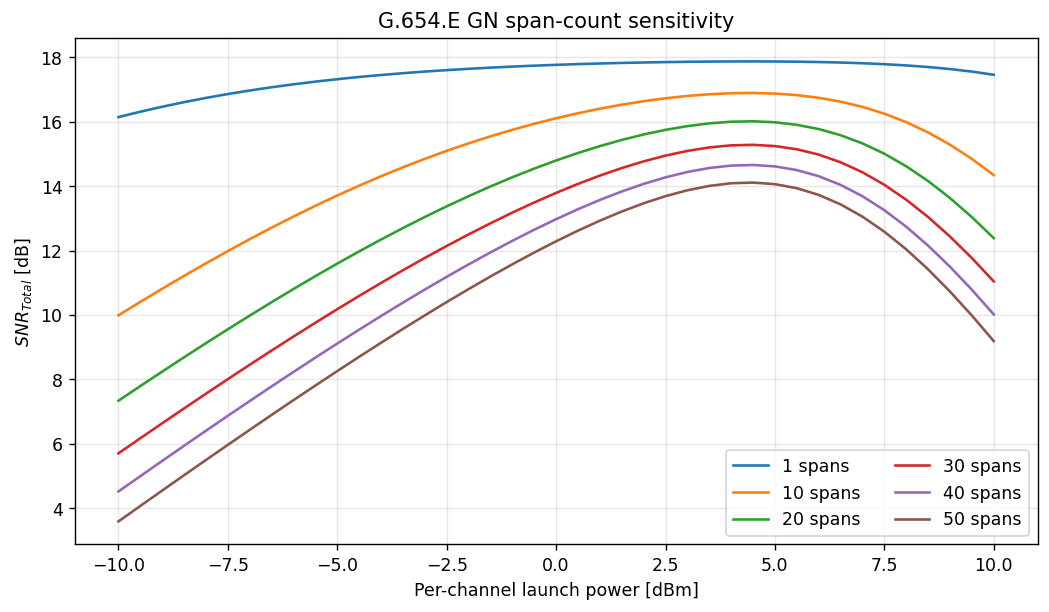

In [6]:
span_cases = [1, 10, 20, 30, 40, 50]
fiber = FIBERS["G.654.E"]
fig, ax = plt.subplots(figsize=(8.5, 5.0))
span_rows = []
for ns in span_cases:
    y = snr_total_db(LAUNCH_DBM, eta_gn["G.654.E"], fiber, n_spans=ns)
    i = int(np.argmax(y))
    span_rows.append({"Spans": ns, "Distance [km]": ns * SPAN_KM,
                      "Optimum [dBm]": LAUNCH_DBM[i], "Max SNR [dB]": y[i]})
    ax.plot(LAUNCH_DBM, y, label=f"{ns} spans")
ax.set(xlabel="Per-channel launch power [dBm]", ylabel=r"$SNR_{Total}$ [dB]",
       title="G.654.E GN span-count sensitivity")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()
display(pd.DataFrame(span_rows).round(2))

## 결론

1. 대표 파라미터와 30-span 가정에서 G.654.E의 GN/GGN 최대점은 첨부 슬라이드의
   **약 4 dBm, 15.3 dB**와 근접합니다.
2. G.654.E는 낮은 loss와 $\gamma$ 때문에 G.652.D보다 최적점의 $SNR_{Total}$이 높습니다.
3. 중심 채널에서는 SRS tilt가 대칭적으로 상쇄되어 GN과 GGN 차이가 매우 작습니다.
   edge-channel/전체 C+L 대역 비교에서는 차이가 더 커질 수 있습니다.
4. 남는 오차의 주요 원인은 슬라이드에 없는 정확한 G.654.E 파라미터, curve의 span 수,
   amplifier passband/주파수별 NF, coherent accumulation 및 실제 gain equalization입니다.